In [10]:
# LEACE Visualization Notebook
#
# This notebook visualizes the effect of LEACE projection:
# 1. Embed sample texts before and after LEACE
# 2. Visualize embeddings with PCA
# 3. Train linear probes to measure demographic leakage
# 4. Calculate Amnesic Drop metric

import sys
sys.path.append('..')

In [ ]:
# Import dependencies
import torch
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

from neuro_stylometry.phase_a_pipeline import PhaseAPipeline
from neuro_stylometry.factories.strategy_factory import StrategyFactory
from neuro_stylometry.pollution_guard.probe import compute_amnesic_drop
from neuro_stylometry.pollution_guard.concept_encoding import DemographicEncoder, extract_probe_labels
from neuro_stylometry.data_engine.schemas import get_demographic_columns
from neuro_stylometry.data_engine.dataset import SOBRDataset

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Initialize pipeline with strict YAML config authority
strategy = StrategyFactory.create_filter_strategy()
pipeline = PhaseAPipeline.from_yaml(strategy=strategy, mode="laptop")

# Access components via facade methods (new API)
embedder = pipeline.get_embedder()
leace = pipeline.get_leace()
detector = pipeline.get_detector()

print("=" * 60)
print("PHASE A PIPELINE CONFIGURATION")
print("=" * 60)
print(f"Embedder model: {embedder.model_name}")
print(f"Embedder device: {embedder.device}")
print(f"Embedder max_length: {embedder.max_length}")
print(f"LEACE embedding_dim: {leace.embedding_dim}")
print(f"LEACE regularization: {leace.regularization}")
print(f"LEACE force_cpu: {leace.force_cpu}")
print(f"GLiNER model: {detector.model_name}")
print(f"GLiNER confidence_threshold: {detector.confidence_threshold}")
print("=" * 60)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedder device: cuda
LEACE force_cpu: True


## 1. Load Data and Compute Embeddings

Load sample posts and extract embeddings before projection.

In [12]:
# Load dataset
dataset_path = Path("../artifacts/data/sobr_laptop.arrow")
dataset = SOBRDataset(arrow_path=dataset_path, seed=int(pipeline.config["seed"]))

# Take a seeded pseudo-random sample (reduces length/padding bias)
sample_size = 200
rng = np.random.default_rng(int(pipeline.config["seed"]))
n_total = len(dataset.table)
take_n = min(sample_size, n_total)
indices = rng.choice(n_total, size=take_n, replace=False)
table = dataset.table.take(pa.array(indices, type=pa.int64))

posts = table["post"].to_pylist()
print(f"Loaded {len(posts)} posts")

# Build multi-demographic concept matrix Z
demo_cols = get_demographic_columns()
demo_encoder = DemographicEncoder(demo_cols).fit(table)
concepts = torch.from_numpy(demo_encoder.transform(table))
print(f"Concept matrix shape: {concepts.shape} (k={concepts.shape[1]})")

# Quick label availability snapshot
avail = {c: int(table[c].null_count) for c in demo_cols}
print("Null counts per demographic (lower is better):")
print(avail)

# Embed posts (batch size sourced from YAML config)
encoder_batch_size = int(pipeline.config["encoder"]["batch_size"])
print("\nEmbedding posts...")
embeddings_before = embedder.embed_texts(posts, batch_size=encoder_batch_size, show_progress=True)
print(f"Embeddings shape: {embeddings_before.shape}")

TypeError: DataType expected, got <class '_cython_3_0_12.cython_function_or_method'>

## 2. Compute LEACE Projection

Compute projection matrix to remove *all* demographic information (all columns in `SOBR_SCHEMA` demographics list) as a single multi-dimensional concept $Z$.

Computing LEACE projection matrix...
Projection matrix shape: torch.Size([768, 768])
Embeddings after projection: torch.Size([200, 768])
Idempotence max|P^2-P|: 1.07e-06
Singular values: min=0.000, median=1.000, max=5.467


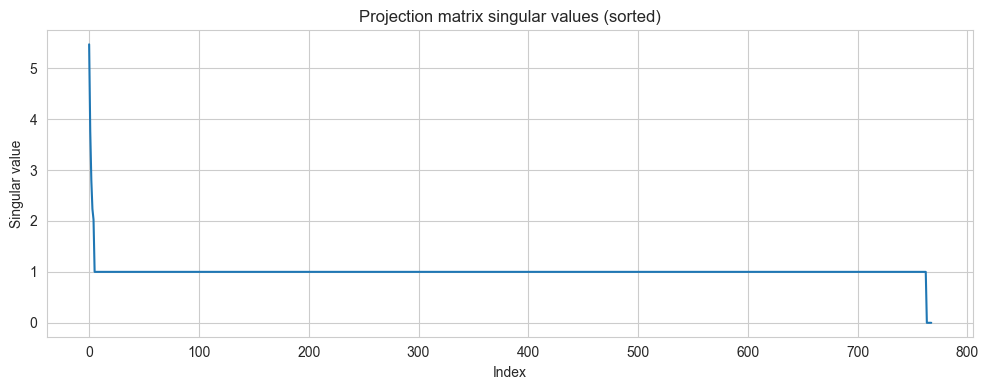

In [ ]:
# Compute projection matrix
print("Computing LEACE projection matrix...")
projection_matrix = leace.compute_projection_from_concepts(embeddings_before, concepts)

projection_matrix_cpu = projection_matrix.detach().to("cpu", dtype=torch.float32)
# Apply projection
embeddings_after = embeddings_before @ projection_matrix_cpu.T

print(f"Projection matrix shape: {projection_matrix.shape}")
print(f"Embeddings after projection: {embeddings_after.shape}")

# Projection diagnostics (aligns with validator expectations)
P = projection_matrix.detach().to("cpu", dtype=torch.float32)
idempotence_err = torch.abs(P @ P - P).max().item()
print(f"Idempotence max|P^2-P|: {idempotence_err:.2e}")

# Singular values as a rough measure of projection impact
sv = torch.linalg.svdvals(P)
sv_np = sv.cpu().numpy()
print(f"Singular values: min={sv_np.min():.3f}, median={np.median(sv_np):.3f}, max={sv_np.max():.3f}")

plt.figure(figsize=(10, 4))
plt.plot(np.sort(sv_np)[::-1])
plt.title("Projection matrix singular values (sorted)")
plt.xlabel("Index")
plt.ylabel("Singular value")
plt.tight_layout()
plt.show()

## 3. Visualize with PCA

Use PCA to visualize embeddings before and after LEACE projection.

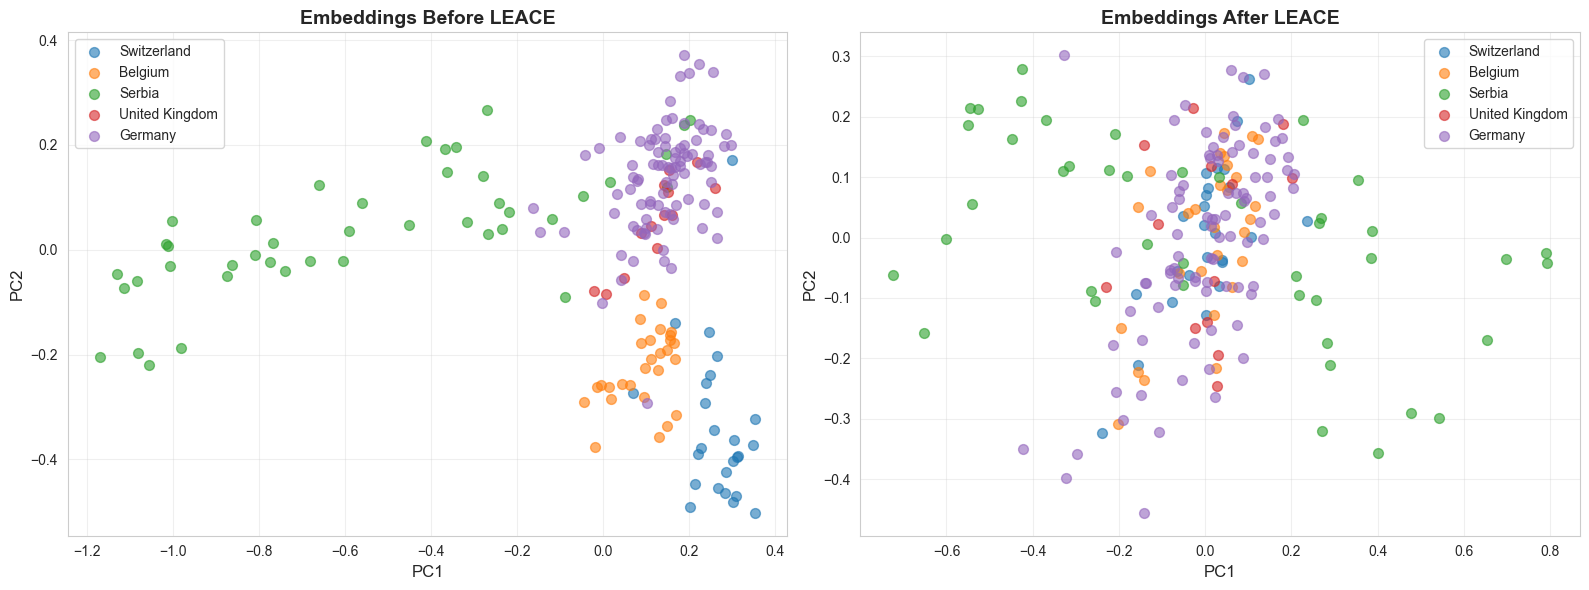

Note: Clusters should be less separated after LEACE projection


In [ ]:
# Apply PCA for visualization
pca_model = PCA(n_components=3)  # Use 3 components for richer visualizations

# Transform before and after
embeddings_before_np = embeddings_before.cpu().numpy()
embeddings_after_np = embeddings_after.cpu().numpy()

pca_before = pca_model.fit_transform(embeddings_before_np)
pca_after = pca_model.fit_transform(embeddings_after_np)

print(f"PCA explained variance ratio (before): {pca_model.explained_variance_ratio_[:3]}")
print(f"PCA cumulative variance (before): {pca_model.explained_variance_ratio_[:3].sum():.2%}")

# Extract labels for multiple demographics
demo_cols = get_demographic_columns()
labels_dict = {}
for col in demo_cols[:3]:  # Use first 3 demographics for visualization
    labels_np = extract_probe_labels(table, col)
    if labels_np is not None:
        labels_dict[col] = labels_np

# Plot PCA comparison for first demographic with most valid labels
primary_demo = max(labels_dict.keys(), key=lambda c: (labels_dict[c] >= 0).sum())
labels_int = labels_dict[primary_demo]
valid_mask = labels_int >= 0
unique_labels = sorted(set(labels_int[valid_mask]))
n_show = min(5, len(unique_labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get color palette
palette = sns.color_palette("husl", n_show)

# Plot before
for i, label_idx in enumerate(unique_labels[:n_show]):
    mask = (labels_int == label_idx)
    axes[0].scatter(
        pca_before[mask, 0],
        pca_before[mask, 1],
        label=f"{primary_demo}={label_idx}",
        alpha=0.6,
        s=50,
        color=palette[i],
    )

axes[0].set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[0].set_title(f'Embeddings Before LEACE (by {primary_demo})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot after
for i, label_idx in enumerate(unique_labels[:n_show]):
    mask = (labels_int == label_idx)
    axes[1].scatter(
        pca_after[mask, 0],
        pca_after[mask, 1],
        label=f"{primary_demo}={label_idx}",
        alpha=0.6,
        s=50,
        color=palette[i],
    )

axes[1].set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[1].set_title(f'Embeddings After LEACE (by {primary_demo})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNote: Clusters should be less separated after LEACE projection")
print(f"Primary demographic used for coloring: {primary_demo}")


## 3c. Embedding Space Metrics

Compute quantitative metrics comparing embedding spaces before and after LEACE.

In [ ]:
# Compute embedding norms
norms_before = torch.norm(embeddings_before, dim=1).cpu().numpy()
norms_after = torch.norm(embeddings_after, dim=1).cpu().numpy()

# Compute pairwise cosine similarities (sample to avoid memory issues)
n_sample_pairs = min(500, len(embeddings_before))
sample_idx = np.random.choice(len(embeddings_before), n_sample_pairs, replace=False)

cos_sim_before = cosine_similarity(embeddings_before_np[sample_idx])
cos_sim_after = cosine_similarity(embeddings_after_np[sample_idx])

# Extract upper triangle (excluding diagonal)
triu_idx = np.triu_indices_from(cos_sim_before, k=1)
cos_sim_before_vals = cos_sim_before[triu_idx]
cos_sim_after_vals = cos_sim_after[triu_idx]

# Create metrics summary
metrics_summary = {
    'Metric': [
        'Embedding norm (mean)',
        'Embedding norm (std)',
        'Cosine similarity (mean)',
        'Cosine similarity (std)',
        'Cosine similarity (median)',
    ],
    'Before LEACE': [
        f"{norms_before.mean():.3f}",
        f"{norms_before.std():.3f}",
        f"{cos_sim_before_vals.mean():.3f}",
        f"{cos_sim_before_vals.std():.3f}",
        f"{np.median(cos_sim_before_vals):.3f}",
    ],
    'After LEACE': [
        f"{norms_after.mean():.3f}",
        f"{norms_after.std():.3f}",
        f"{cos_sim_after_vals.mean():.3f}",
        f"{cos_sim_after_vals.std():.3f}",
        f"{np.median(cos_sim_after_vals):.3f}",
    ],
}

metrics_df = pd.DataFrame(metrics_summary)
print("=" * 80)
print("EMBEDDING SPACE METRICS")
print("=" * 80)
display(metrics_df)
print("=" * 80)

# Plot norm distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(norms_before, bins=30, alpha=0.7, label='Before', color='steelblue')
axes[0].hist(norms_after, bins=30, alpha=0.7, label='After', color='coral')
axes[0].set_xlabel('Embedding Norm', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Embedding Norm Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot cosine similarity distributions
axes[1].hist(cos_sim_before_vals, bins=30, alpha=0.7, label='Before', color='steelblue', density=True)
axes[1].hist(cos_sim_after_vals, bins=30, alpha=0.7, label='After', color='coral', density=True)
axes[1].set_xlabel('Cosine Similarity', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Pairwise Cosine Similarity Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: LEACE may change embedding norms and similarity distributions.")


## 3b. Scatter Matrix for PCA Components

Create scatter matrix plots showing relationships between PCA components colored by demographics.

In [ ]:
# Create scatter matrix for PCA components (before LEACE)
n_components = min(3, pca_before.shape[1])

# Create DataFrame for seaborn pairplot
df_before = pd.DataFrame(
    pca_before[:, :n_components],
    columns=[f'PC{i+1}' for i in range(n_components)]
)
df_before[primary_demo] = labels_int

# Only plot valid labels
df_before_valid = df_before[df_before[primary_demo] >= 0].copy()
df_before_valid[primary_demo] = df_before_valid[primary_demo].astype(str)

# Create pairplot
print(f"Creating scatter matrix for {n_components} PCA components (before LEACE)...")
g = sns.pairplot(
    df_before_valid,
    hue=primary_demo,
    palette="husl",
    plot_kws={'alpha': 0.6, 's': 30},
    diag_kind='kde',
)
g.fig.suptitle(f'PCA Component Relationships (Before LEACE) - Colored by {primary_demo}', 
               y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Create scatter matrix for after LEACE
df_after = pd.DataFrame(
    pca_after[:, :n_components],
    columns=[f'PC{i+1}' for i in range(n_components)]
)
df_after[primary_demo] = labels_int

df_after_valid = df_after[df_after[primary_demo] >= 0].copy()
df_after_valid[primary_demo] = df_after_valid[primary_demo].astype(str)

print(f"Creating scatter matrix for {n_components} PCA components (after LEACE)...")
g = sns.pairplot(
    df_after_valid,
    hue=primary_demo,
    palette="husl",
    plot_kws={'alpha': 0.6, 's': 30},
    diag_kind='kde',
)
g.fig.suptitle(f'PCA Component Relationships (After LEACE) - Colored by {primary_demo}', 
               y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNote: After LEACE, demographic clusters should be less distinguishable.")


## 4. Compute Amnesic Drop

Train linear probes to measure demographic leakage before and after LEACE.

Computing Amnesic Drop metric...



c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib

Seeds: [0, 1, 2]
Accuracy before (mean±std): 82.5% ± 7.4%
Accuracy after  (mean±std): 43.3% ± 7.7%
Amnesic drop    (mean±std): 47.9% ± 5.7%


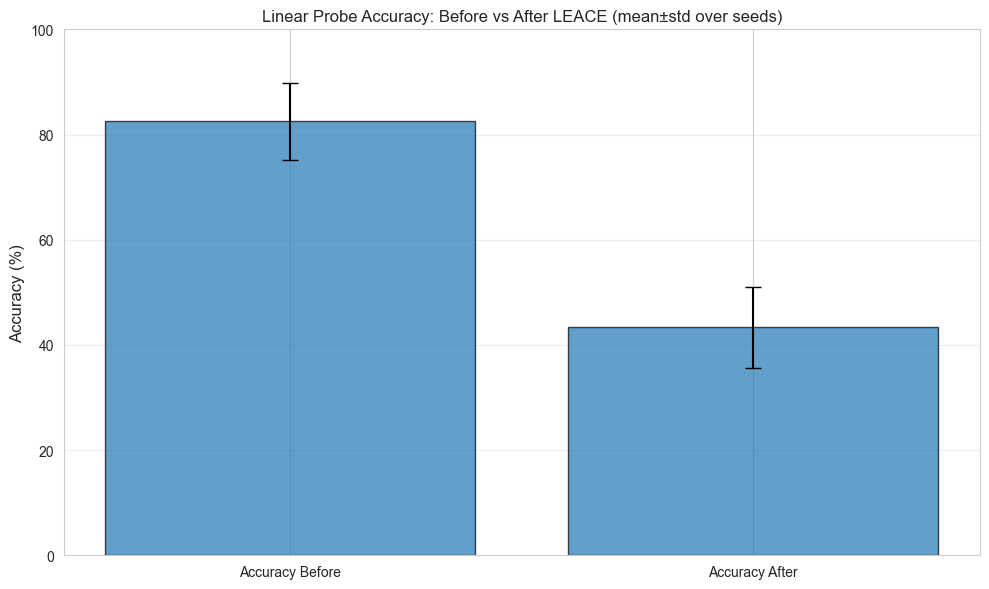


AMNESIC DROP SUMMARY
Idempotence max|P^2-P|: 1.07e-06
Amnesic Drop (mean):     47.9%
Threshold:              30.0%

✓ Target achieved


In [ ]:
# Compute amnesic drop per-demographic (repeat across multiple seeds for stability)
print("Computing Amnesic Drop metrics per demographic...\n")

seeds = [0, 1, 2]
demo_cols = get_demographic_columns()

results_by_col = {}
detailed_results = []

for col in demo_cols:
    labels_np = extract_probe_labels(table, col)
    if labels_np is None:
        continue
    
    labels = torch.tensor(labels_np, dtype=torch.long)
    
    # Check if we have enough samples
    valid_labels = labels >= 0
    if valid_labels.sum() < 10:
        print(f"Skipping {col}: insufficient valid labels ({valid_labels.sum()} < 10)")
        continue

    col_results = []
    for s in seeds:
        acc_before, acc_after, amnesic_drop = compute_amnesic_drop(
            embeddings_before=embeddings_before,
            embeddings_after=embeddings_after,
            labels=labels,
            train_split=float(pipeline.config["probe"]["train_split"]),
            random_state=s,
        )
        col_results.append((acc_before, acc_after, amnesic_drop))
        detailed_results.append({
            'demographic': col,
            'seed': s,
            'acc_before': acc_before,
            'acc_after': acc_after,
            'amnesic_drop': amnesic_drop,
        })
    
    results_by_col[col] = col_results

# Aggregate summary
summary = []
for col, col_results in results_by_col.items():
    acc_before_vals = np.array([r[0] for r in col_results], dtype=float)
    acc_after_vals = np.array([r[1] for r in col_results], dtype=float)
    drop_vals = np.array([r[2] for r in col_results], dtype=float)
    summary.append({
        "demographic": col,
        "acc_before_mean": float(acc_before_vals.mean()),
        "acc_before_std": float(acc_before_vals.std(ddof=0)),
        "acc_after_mean": float(acc_after_vals.mean()),
        "acc_after_std": float(acc_after_vals.std(ddof=0)),
        "drop_mean": float(drop_vals.mean()),
        "drop_std": float(drop_vals.std(ddof=0)),
    })

summary_df = pd.DataFrame(summary).sort_values("drop_mean", ascending=True)

print("=" * 100)
print("PROBE ACCURACY SUMMARY (MEAN ± STD OVER SEEDS)")
print("=" * 100)
display(summary_df)
print("=" * 100)

# Detailed results table
detailed_df = pd.DataFrame(detailed_results)
print("\nDetailed Per-Seed Results:")
display(detailed_df.head(15))

# Weakest-link metric
min_drop = float(summary_df["drop_mean"].min()) if len(summary_df) else 0.0
threshold = float(pipeline.config["probe"]["amnesic_drop_threshold"])

# Plot accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot before/after accuracies
x = np.arange(len(summary_df))
width = 0.35
axes[0].bar(x - width/2, summary_df["acc_before_mean"], width, 
            yerr=summary_df["acc_before_std"], label='Before LEACE', 
            alpha=0.8, capsize=4, color='steelblue')
axes[0].bar(x + width/2, summary_df["acc_after_mean"], width,
            yerr=summary_df["acc_after_std"], label='After LEACE', 
            alpha=0.8, capsize=4, color='coral')
axes[0].set_ylabel('Probe Accuracy', fontsize=12)
axes[0].set_xlabel('Demographic', fontsize=12)
axes[0].set_title('Linear Probe Accuracy: Before vs After LEACE', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_df["demographic"], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Plot amnesic drops
axes[1].bar(summary_df["demographic"], summary_df["drop_mean"], 
            yerr=summary_df["drop_std"], capsize=4, alpha=0.8, color='forestgreen')
axes[1].axhline(threshold, color="red", linestyle="--", linewidth=2, 
                label=f"threshold={threshold:.0%}")
axes[1].set_ylabel('Amnesic Drop (mean±std)', fontsize=12)
axes[1].set_xlabel('Demographic', fontsize=12)
axes[1].set_title('Per-Demographic Amnesic Drop', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(summary_df["demographic"], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "=" * 80)
print("AMNESIC DROP SUMMARY (WEAKEST LINK)")
print("=" * 80)
print(f"Idempotence max|P^2-P|:           {idempotence_err:.2e}")
print(f"Min mean drop across demographics: {min_drop:.1%}")
print(f"Target threshold:                  {threshold:.1%}")
print()
if min_drop >= threshold:
    print("✓ Target achieved: All demographics exceed threshold")
else:
    weakest = summary_df.iloc[0]
    print(f"✗ Target not met: Weakest demographic is '{weakest['demographic']}' ({weakest['drop_mean']:.1%})")
print("=" * 80)


## 5. Cross-Demographic Confusion Analysis

Analyze if LEACE reduces cross-demographic classification patterns.

In [ ]:
# Analyze cross-demographic relationships
# For each pair of demographics, measure classification improvement

cross_demo_results = []

for demo1, demo2 in combinations(list(results_by_col.keys())[:4], 2):  # Top 4 demographics
    # Get labels
    labels1 = extract_probe_labels(table, demo1)
    labels2 = extract_probe_labels(table, demo2)
    
    if labels1 is None or labels2 is None:
        continue
    
    # Find samples with both labels valid
    valid_mask = (labels1 >= 0) & (labels2 >= 0)
    if valid_mask.sum() < 10:
        continue
    
    cross_demo_results.append({
        'demo1': demo1,
        'demo2': demo2,
        'n_samples': int(valid_mask.sum()),
    })

if cross_demo_results:
    cross_df = pd.DataFrame(cross_demo_results)
    print("=" * 80)
    print("CROSS-DEMOGRAPHIC SAMPLE AVAILABILITY")
    print("=" * 80)
    display(cross_df)
    print("=" * 80)
    print("\nNote: Samples with multiple demographic labels available allow")
    print("cross-demographic probing to assess information leakage patterns.")
else:
    print("Insufficient cross-demographic samples for analysis.")
